In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [3]:
df = pd.read_csv('IDH+test.data_Dryad.csv')

In [4]:
print("Dataset Shape:", df.shape)
print("\nMissing Values Summary:")
missing = df.isnull().sum()
print(missing[missing > 0])

# Drop completely empty columns
df.dropna(axis=1, how='all', inplace=True)

Dataset Shape: (761, 64)

Missing Values Summary:
FreqofLLITN2       196
Typeofcomplaint    577
ART                  2
ARTstartyear       145
ARTtype              3
BSMMP               30
Comment            761
dtype: int64


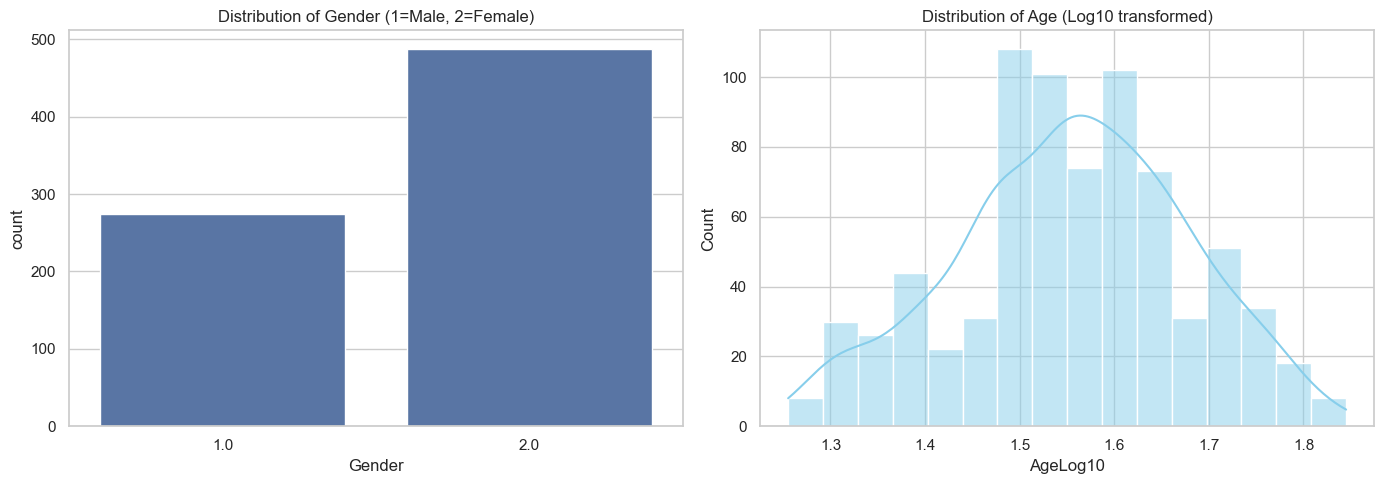

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Gender Distribution (Assume 1=Male, 2=Female based on common coding)
sns.countplot(data=df, x='Gender', ax=ax[0])
ax[0].set_title('Distribution of Gender (1=Male, 2=Female)')

# Age Distribution (using Log scale provided in dataset)
sns.histplot(df['AgeLog10'], kde=True, ax=ax[1], color='skyblue')
ax[1].set_title('Distribution of Age (Log10 transformed)')
plt.tight_layout()
plt.show()

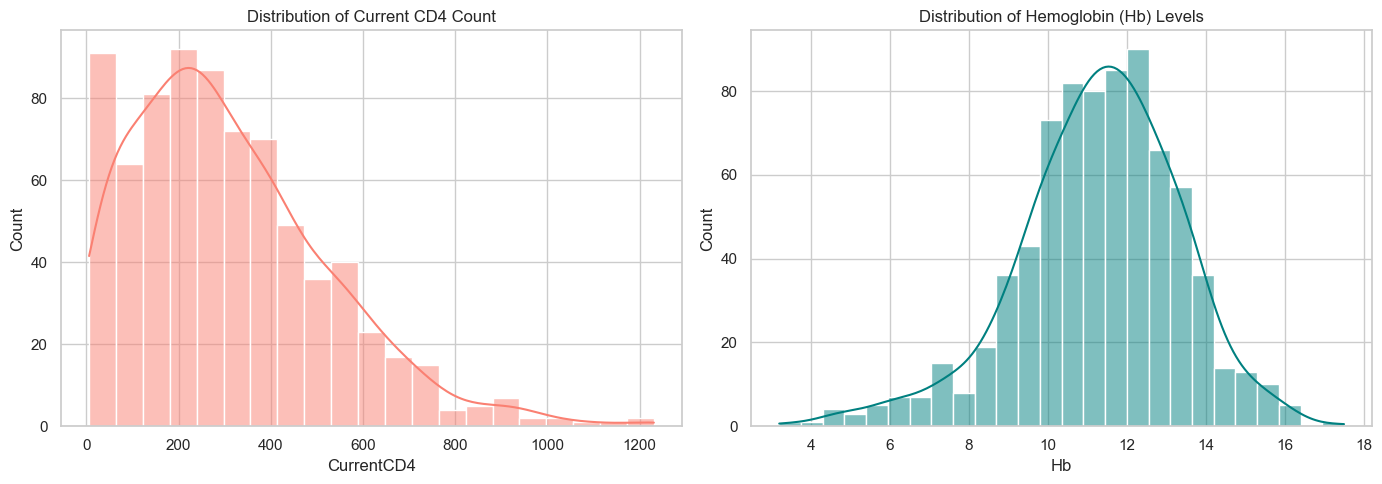

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Current CD4 Count Distribution
sns.histplot(df['CurrentCD4'], kde=True, ax=ax[0], color='salmon')
ax[0].set_title('Distribution of Current CD4 Count')

# Hemoglobin (Hb) Levels
sns.histplot(df['Hb'], kde=True, ax=ax[1], color='teal')
ax[1].set_title('Distribution of Hemoglobin (Hb) Levels')
plt.tight_layout()
plt.show()

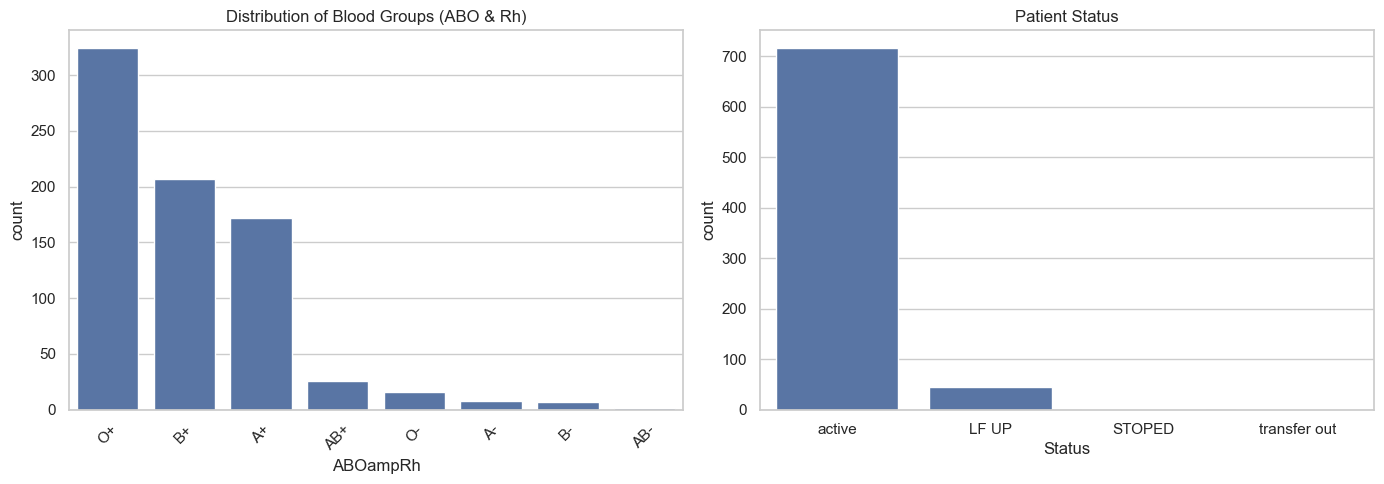

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# ABO and Rh Group Distribution
sns.countplot(data=df, x='ABOampRh', ax=ax[0], order=df['ABOampRh'].value_counts().index)
ax[0].set_title('Distribution of Blood Groups (ABO & Rh)')
ax[0].tick_params(axis='x', rotation=45)

# ART Status
sns.countplot(data=df, x='Status', ax=ax[1])
ax[1].set_title('Patient Status')
plt.tight_layout()
plt.show()

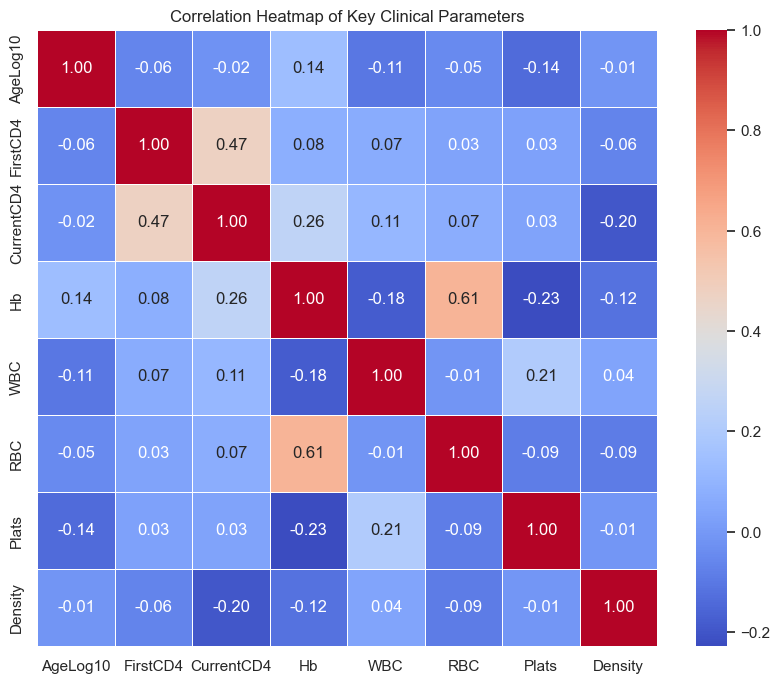

In [10]:
# Selecting key numerical/clinical columns for correlation
cols_to_corr = ['AgeLog10', 'FirstCD4', 'CurrentCD4', 'Hb', 'WBC', 'RBC', 'Plats', 'Density']
corr_matrix = df[cols_to_corr].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Key Clinical Parameters')
plt.show()

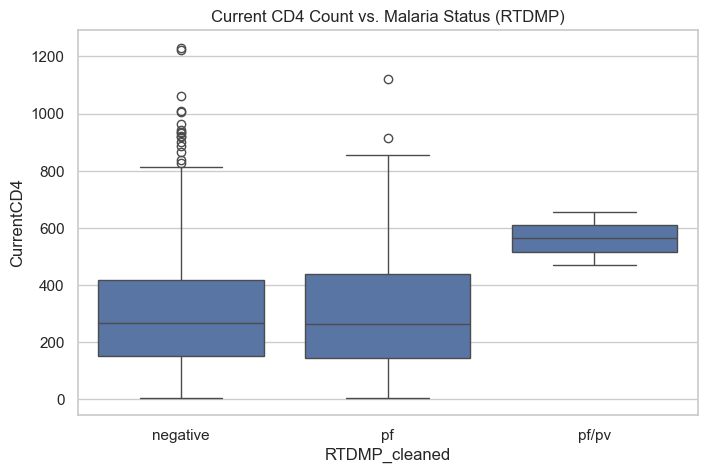

In [14]:
# Cleaning RTDMP values for consistency
df['RTDMP_cleaned'] = df['RTDMP'].astype(str).str.lower().replace('0', 'negative')

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='RTDMP_cleaned', y='CurrentCD4')
plt.title('Current CD4 Count vs. Malaria Status (RTDMP)')
plt.show()

In [15]:
print("\nDescriptive Statistics for Key Clinical Variables:")
display(df[['AgeLog10', 'CurrentCD4', 'Hb', 'WBC', 'RBC']].describe())


Descriptive Statistics for Key Clinical Variables:


,AgeLog10,CurrentCD4,Hb,WBC,RBC
count,761.000000,761.000000,761.000000,761.000000,761.000000
mean,1.554577,309.501971,11.284100,6.117845,3.885361
std,0.123052,214.642825,2.072463,2.720005,0.700961
min,1.255273,6.000000,3.200000,1.200000,1.740000
25%,1.477121,149.000000,10.100000,4.600000,3.430000
50%,1.556303,265.000000,11.400000,5.700000,3.840000
75%,1.653213,427.000000,12.700000,7.000000,4.340000
max,1.845098,1231.000000,17.500000,38.500000,6.020000
